In [1]:
'''
In this file, we will work on implementing the Zermelo problem, with some new changes:
- No obstacles
- The state evolution will be deterministic, as it is when one specifies a flight trajectory
- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity
- Of course, it may be difficult to balance this with the cost associated to reaching the destination
- We will set harsh constraints on the maximum and minimum velocities via a sigmoid
- We will model vertical wind via a Brownian bridge from w_min to w_max. No horizontal component just yet

It will be interesting also to investigate whether randomised base policies help (to augment the reference trajectories)
'''

'\nIn this file, we will work on implementing the Zermelo problem, with some new changes:\n- No obstacles\n- The state evolution will be deterministic, as it is when one specifies a flight trajectory\n- The pseudoloss will aim to encapsulate fuel cost by penalising the cubic of the difference between prescribed and wind velocity\n- Of course, it may be difficult to balance this with the cost associated to reaching the destination\n- We will set harsh constraints on the maximum and minimum velocities via a sigmoid\n- We will model vertical wind via a Brownian bridge from w_min to w_max. No horizontal component just yet\n\nIt will be interesting also to investigate whether randomised base policies help (to augment the reference trajectories)\n'

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
import time
import os
from ipywidgets import interact, IntSlider

In [3]:
# will aim to traverse from (-50, 0) to (50, 0).
# speed of reference trajectories will be 10 units per time step, thus we use time horizon of 10 steps
# will experiment with values for w_min and w_max

def OU_process(x0, sd, theta, mu, sigma, T, time_step):
    total_steps = int(T / time_step)
    process = np.zeros(total_steps + 1, dtype = float)
    process[0] = np.random.normal(loc = x0, scale = sd)
    for t in range(total_steps):
        process[t + 1] = process[t] + theta * (mu - process[t]) * time_step + sigma * np.sqrt(time_step) * np.random.normal()
    return process.astype(np.float32)

def winds(a, b, T, time_step, sigma, theta):
    """
    Simulate OU processes around a and b, then interpolate over the time steps to create an approximate move from a to b over time T, 
    kind of like a wind forecast
    """
    # don't bother with hyperparameters for OU process, just input here
    total_steps = int(T / time_step)
    ou_a = OU_process(a, 0.1, theta, a, sigma, T, time_step)
    ou_b = OU_process(b, 0.1, theta, b, sigma, T, time_step)[::-1]
    interpolants_b = np.linspace(0, 1, total_steps + 1, dtype = np.float32)
    interpolants_a = 1 - interpolants_b
    wind_process = interpolants_a * ou_a + interpolants_b * ou_b
    return wind_process.astype(np.float32)

Text(0.5, 1.0, 'Sample Winds')

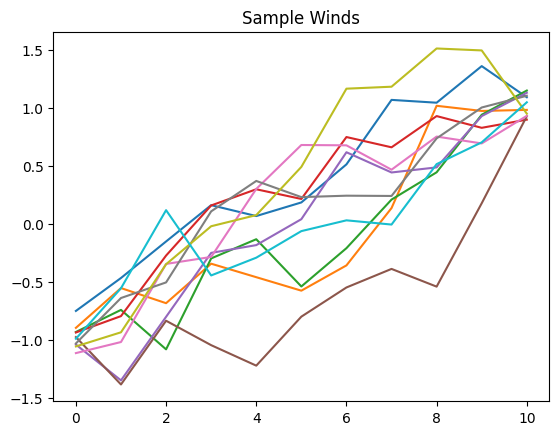

In [7]:
for i in range(10):
    plt.plot(winds(-1, 1, 10, 1, 0.4, 0.1))
plt.title("Sample Winds")

In [8]:
# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
torch.set_default_dtype(torch.float32)
print("Running on:", device)

Running on: mps


In [9]:
# define control NNs
class NeuralNet_erm(nn.Module):
    def __init__(self, input_dim, width, output_dim):
        super(NeuralNet_erm, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, width)
        self.hidden_layer_2 = nn.Linear(width, width)
        self.hidden_layer_3 = nn.Linear(width, width)
        self.hidden_layer_4 = nn.Linear(width, width)
        self.sigmoid = nn.LeakyReLU()
        self.output_layer = nn.Linear(width, output_dim)
        
    def forward(self, x):
        activations_1 = self.sigmoid(self.hidden_layer(x))
        activations_2 = self.sigmoid(self.hidden_layer_2(activations_1))
        activations_3 = self.sigmoid(self.hidden_layer_3(activations_2))
        activations_4 = self.sigmoid(self.hidden_layer_4(activations_3))
        unscaled = self.output_layer(activations_4)
        return unscaled

# loss function (wind cost + terminal cost)
def running_loss(wind_value, velocity):
    a = velocity.shape[0]
    b = velocity.shape[1]
    zeros_vecs = torch.zeros((a, b, 1), device = device)
    wind_vector = torch.cat([zeros_vecs, wind_value.view(a, b, 1)], dim  = 2)
    wind_cost = torch.norm(wind_vector - velocity, dim = 2)
    return wind_cost

def terminal_loss(position, target):
    ones_vec = torch.ones_like(position, device = device)
    target_matrix = ones_vec * target
    final_cost = torch.norm(position - target_matrix, dim = 1) ** 2
    return final_cost

# def penalising_velocity(velocity, min_speed, max_speed, multiplier, steepness):
#     speed = torch.norm(velocity, dim = 2) # since velocities is 3D tensor
#     min_cost = torch.sigmoid(steepness * (min_speed - speed))
#     max_cost = torch.sigmoid(steepness * (speed - max_speed))
#     return multiplier * torch.relu(min_cost + max_cost - 0.5)

def penalising_velocity(velocity, min_speed, max_speed, multiplier, steepness):
    speed = torch.norm(velocity, dim = 2) # since velocities is 3D tensor
    return multiplier * (torch.relu(speed - max_speed) ** 2 + torch.relu(min_speed - speed) ** 2)

# base policy randomiser function
def random_base_policy(num_policies, num_steps, min_angle, max_angle, base_speed):
    angle_matrix = torch.rand((num_policies, num_steps), device = device) * (max_angle - min_angle) + min_angle
    velocities = torch.stack((torch.cos(angle_matrix), torch.sin(angle_matrix)), dim= -1) * base_speed
    return velocities

pi_tensor = torch.tensor(math.pi, device = device)
two_tensor = torch.tensor(2.0, device = device)
# write the collision-avoidance loss function
def collision_avoidance_loss(positions1, positions2, velocities1, velocities2, T, time_gap, min_distance, collision_multiplier):
    epsilon = 1e-6
    s = min_distance / torch.sqrt(torch.log(two_tensor)) 
    curr_t = T - velocities1.shape[1]
    taus = torch.linspace(0, T, steps = int(T / time_gap) + 1, device = device)[curr_t:-1] # no need to include final time
    dx = positions1 - positions2
    distances = torch.norm(dx, dim = 2) # collapses to (num_policies * n, num_steps)
    distances = torch.clamp(distances, min = 1e-3) # avoid division by zero
    dv = velocities1 - velocities2 
    magvs = torch.norm(dv, dim = 2) 
    magvs = torch.clamp(magvs, min = 1e-3) # avoid division by zero
    dotxv = torch.sum(dx * dv, dim = 2)
    exponent = (dotxv / magvs) ** 2 / 4 - distances
    exponent = torch.clamp(exponent, min=-100, max=100)
    exp_component = torch.exp(exponent / (s ** 2))
    # print(dotxv)
    # print(magvs)
    # print(distances)
    factor = collision_multiplier * ( s * torch.sqrt(pi_tensor)) / (2 * magvs)
    time1 = magvs / s * (taus + dotxv / (2 * magvs ** 2 + epsilon))
    time2 = magvs / s * (taus + dotxv / (2* magvs ** 2 + epsilon) + time_gap)
    collision_costs = factor * exp_component * (torch.erf(time2) - torch.erf(time1))
    return torch.relu(collision_costs - time_gap / 2) # gets rid of penalties from outside radius

In [10]:
# visualise trajectories for a set of random base policies
num_policies = 50
num_steps = 10
base_speed = 10.0
policies = random_base_policy(num_policies, num_steps, - 3 * math.pi / 8, math.pi / 8, 11.5)
start = torch.tensor([-50.0, 25.0], device = device)
base_trajectories = torch.zeros((num_policies, num_steps + 1, 2), device = device)
base_trajectories[:, 0, :] = start
# for t in range(num_steps):
#     base_trajectories[:, t + 1, :] = base_trajectories[:, t, :] + policies[:, t, :]
starts = torch.ones((num_policies, 1, 2), device = device) * start
trajectories = torch.cumsum(policies, dim = 1) + torch.tensor([-50, 25], device = device)
trajectories = torch.cat((starts, trajectories), dim = 1)

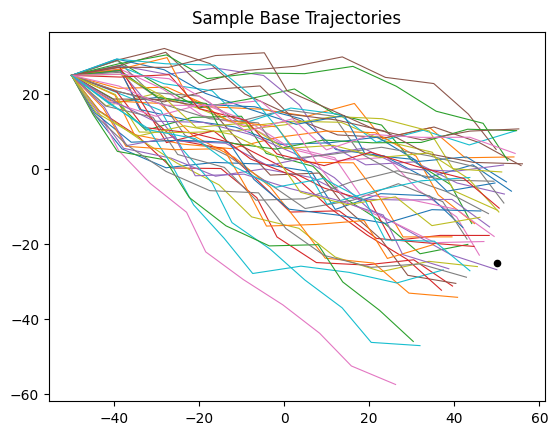

In [11]:
plt.plot(trajectories[:,:,0].cpu().numpy().T, trajectories[:,:,1].cpu().numpy().T, linewidth = 0.8)
plt.title("Sample Base Trajectories")
plt.scatter(50, -25, s = 20, color = "black")
plt.show()

In [12]:
# now, note that our training dataset will be augmented to num_sample * num_policies
def generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta):
    training_data = torch.zeros((n * num_policies, int(T / time_step)), device = device)
    for i in range(n):
        bridge = torch.tensor(winds(a, b, T, time_step, sigma, theta)[: -1], device = device)
        bridge = bridge.repeat(num_policies, 1)
        training_data[i * num_policies : (i + 1) * num_policies, :] = bridge
    return training_data

In [13]:
generate_training_data(-1, 1, 10, 1, 5, 3, 0.2, 0.1)

tensor([[-1.0361, -0.7063, -0.5469, -0.1707, -0.0414,  0.4316,  0.4859,  0.8397,
          1.0038,  0.9385],
        [-1.0361, -0.7063, -0.5469, -0.1707, -0.0414,  0.4316,  0.4859,  0.8397,
          1.0038,  0.9385],
        [-1.0361, -0.7063, -0.5469, -0.1707, -0.0414,  0.4316,  0.4859,  0.8397,
          1.0038,  0.9385],
        [-1.0038, -0.8381, -1.0126, -1.0684, -0.6984, -0.7527, -0.2068,  0.2340,
          0.3379,  0.6038],
        [-1.0038, -0.8381, -1.0126, -1.0684, -0.6984, -0.7527, -0.2068,  0.2340,
          0.3379,  0.6038],
        [-1.0038, -0.8381, -1.0126, -1.0684, -0.6984, -0.7527, -0.2068,  0.2340,
          0.3379,  0.6038],
        [-1.0349, -1.0644, -0.7355, -0.4950, -0.2889, -0.2205, -0.0946,  0.3553,
          0.5614,  0.8975],
        [-1.0349, -1.0644, -0.7355, -0.4950, -0.2889, -0.2205, -0.0946,  0.3553,
          0.5614,  0.8975],
        [-1.0349, -1.0644, -0.7355, -0.4950, -0.2889, -0.2205, -0.0946,  0.3553,
          0.5614,  0.8975],
        [-0.9039, -

In [18]:
# hyperparameters
input_dim = 3
width = 500
output_dim = 2
v_min = 7
v_max = 23
velocity_penalty_multiplier = 1000
n = 20
num_policies = 60
T = 10
time_step = 1
num_steps = int(T / time_step)
base_speed = 11.3
a = -1
b = 1
start_rate = 0.0001
final_rate = 0.0000000001
num_epochs = 5000
target = torch.tensor([50.0, -25.0], device = device)
steepness = 5
sigma = 0.2
theta = 0.1
outer_loops = 4

In [16]:
Zs = np.linspace(-2, 2, 20)

# Create grid
xs = np.linspace(-50, 50, 50)
ys = np.linspace(-50, 50, 50)
X, Y = np.meshgrid(xs, ys)

def plot_quiver(model_idx, z_idx):
    model = models_erm[model_idx]
    z = Zs[z_idx]
    xy = np.stack([X.ravel(), Y.ravel(), np.full_like(X.ravel(), z)], axis=1)
    xy_tensor = torch.tensor(xy, dtype=torch.float32, device = device)
    with torch.no_grad():
        output = model(xy_tensor).cpu().numpy()

    U = output[:,0].reshape(X.shape)
    V = output[:,1].reshape(X.shape)

    # Plot quiver
    plt.figure(figsize=(10,5))
    plt.quiver(X, Y, U, V, scale = 1000)

    for pth in range(n):
        plt.plot(current_paths[pth * num_policies, :model_idx + 1, 0].detach().cpu().numpy(), 
                 current_paths[pth * num_policies, :model_idx + 1, 1].detach().cpu().numpy(), color = 'red', linewidth = 0.5, alpha = 0.9)
        plt.plot(current_paths[pth * num_policies, model_idx:, 0].detach().cpu().numpy(), 
                 current_paths[pth * num_policies, model_idx:, 1].detach().cpu().numpy(), color = 'blue', linewidth = 0.5, alpha = 0.9)
        
    plt.title(f"PyTorch Quiver Plot | Model {model_idx+1} | Z = {z}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.xlim(-50, 50)
    plt.ylim(-50, 50)
    plt.grid(True)
    plt.show()

In [17]:
''' New idea:
Since we are modelling deterministically, instead of penalising the terminal cost as squared distance to target, 
we can just set it to be the required remaining velocity to hit the target perfectly (a deterministic object!), 
and penalise the resulting velocity decision accordingly (which is a function of T-1 th model)
'''
# generate the training data
training_data = generate_training_data(a, b, T, time_step, n, num_policies, sigma, theta)

# will also need the reference trajectories (same set of num_policies for each sample)
ref_paths = torch.zeros((n * num_policies, num_steps + 1, 2), device = device)
starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-50, 25], device = device)
for i in range(n):
    base_policies = random_base_policy(num_policies, num_steps, - 3 * math.pi / 8, math.pi / 8, base_speed)
    starts = torch.ones((num_policies, 1, 2), device = device) * torch.tensor([-50, 25], device = device)
    ref_pathsi = torch.cumsum(base_policies, dim = 1) + torch.tensor([-50, 25], device = device)
    ref_pathsi = torch.cat((starts, ref_pathsi), dim = 1)
    # repeat for each instance of the training samples
    # ref_paths = ref_paths.repeat(n, 1, 1)
    ref_paths[i * num_policies : (i + 1) * num_policies, :, :] = ref_pathsi
# training data and reference paths now fully constructed
# initialise models, optimisers and schedulers
models_erm = [NeuralNet_erm(input_dim, width, output_dim).to(device) for _ in range(T - 1)] # final velocity is a function of prior one now
optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]

In [331]:
for loop in range(outer_loops):
    print(f"Outer loop {loop + 1}")
    for t in reversed(range(T - 1)):
        print(f"t = {t}")
        path_length = T - t
        for epoch in range(num_epochs):
            final_c = 0
            current_paths = [ref_paths[:, t, :]]
            velocities = []
            # generate path from t
            for futs in range(path_length - 1): # up until T-1 then final velocity calculated separately
                velocity = models_erm[t + futs](torch.cat([current_paths[-1],
                                                        training_data[:, t + futs].view(n * num_policies, 1)], 
                                                        dim = 1))
                current_paths.append(current_paths[-1] + time_step * velocity)
                velocities.append(velocity)
            # final velocity to hit target exactly
            final_velocity = (target - current_paths[-1]) / time_step
            velocities.append(final_velocity)
            # stack into 3D tensors
            current_paths = torch.stack(current_paths, dim = 1)
            to_add = target.repeat(n * num_policies, 1).view(n * num_policies, 1, 2)
            current_paths = torch.cat([current_paths, to_add], dim = 1)
            velocities = torch.stack(velocities, dim = 1)
            # compute losses
            safety_costs = penalising_velocity(velocities, v_min, v_max, velocity_penalty_multiplier, steepness)
            safety_costs = torch.sum(safety_costs, dim = 1)
            running_losses = running_loss(training_data[:, t:], velocities)
            running_costs = torch.sum(running_losses, dim = 1) / (T)  # kind of normalises
            final_c = final_c + torch.mean(safety_costs + running_costs)
            # backprop
            final_c.backward()
            optimisers[t].step()
            optimisers[t].zero_grad()
            schedulers[t].step()
            if epoch % 1000 == 0:
                with torch.no_grad():
                    print(f"Epoch {epoch}, Total {final_c:.6f}, Safety {torch.mean(safety_costs):.6f}, Running {torch.mean(running_costs):.6f}")
        # freeze model after training
        for param in models_erm[t].parameters():
            param.requires_grad = False
    for model in models_erm:
        for param in model.parameters():
            param.requires_grad = True
    # reset optimisers and schedulers
    optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
    schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]
    # new reference policies are the learned policies for this loop
    ref_paths = current_paths.detach()

Outer loop 1
t = 8
Epoch 0, Total 22897.755859, Safety 22894.033203, Running 3.724081
Epoch 1000, Total 50.258450, Safety 46.582531, Running 3.675920
Epoch 2000, Total 43.739594, Safety 40.101746, Running 3.637852
Epoch 3000, Total 43.661274, Safety 40.028008, Running 3.633267
Epoch 4000, Total 43.725216, Safety 40.092697, Running 3.632524
Epoch 5000, Total 43.673115, Safety 40.041023, Running 3.632087
Epoch 6000, Total 43.629860, Safety 39.998020, Running 3.631839
Epoch 7000, Total 43.612324, Safety 39.980595, Running 3.631731
Epoch 8000, Total 43.611153, Safety 39.979488, Running 3.631664
Epoch 9000, Total 43.610550, Safety 39.978912, Running 3.631634
t = 7
Epoch 0, Total 6617.982910, Safety 6613.361816, Running 4.621313
Epoch 1000, Total 4.902121, Safety 0.149186, Running 4.752935
Epoch 2000, Total 4.616354, Safety 0.003535, Running 4.612818
Epoch 3000, Total 4.568254, Safety 0.000162, Running 4.568092
Epoch 4000, Total 4.563586, Safety 0.000047, Running 4.563539
Epoch 5000, Total 4

Text(0.5, 1.0, 'Learned Trajectories')

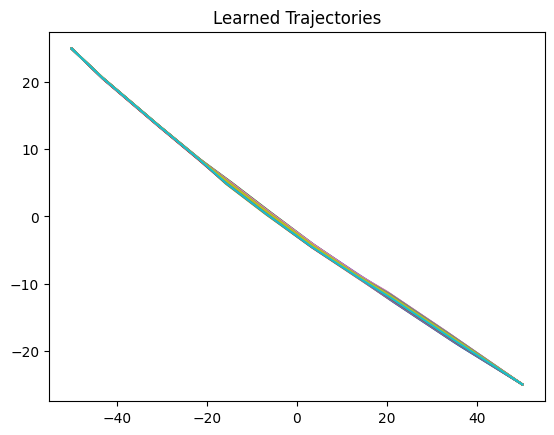

In [332]:
for pth in range(n):
    plt.plot(current_paths[pth * num_policies, :, 0].detach().cpu().numpy(), 
             current_paths[pth * num_policies, :, 1].detach().cpu().numpy())
plt.title("Learned Trajectories")

In [ ]:
interact(
    plot_quiver,
    model_idx=IntSlider(min=0, max=len(models_erm)-1, step=1, description='Model'),
    z_idx=IntSlider(min=0, max=len(Zs)-1, step=1, description='Z index')
)
plt.show()

interactive(children=(IntSlider(value=0, description='Model', max=8), IntSlider(value=0, description='Z index'…

<Axes: >

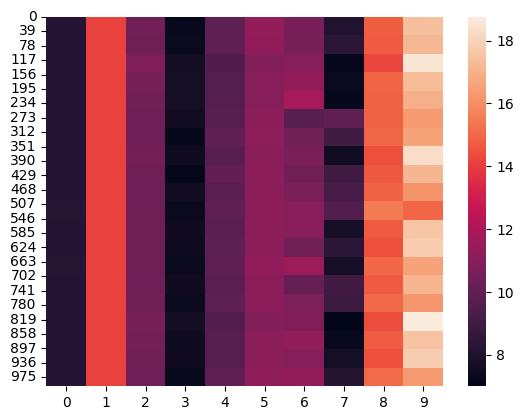

In [334]:
magvs = torch.norm(velocities,dim =2)
import seaborn as sns
sns.heatmap(magvs.detach().cpu().numpy())

In [ ]:
'''
Now we extend to two planes, by just adding another plane on top of this problem.

Same start time, end time, and wind conditions, but different start and target positions.


'''


pi_tensor = torch.tensor(math.pi, device = device)
two_tensor = torch.tensor(2.0, device = device)

In [103]:
# hyperparameters
input_dim = 3
width = 500
output_dim = 2
v_min = 1
v_max = 8
velocity_penalty_multiplier = 50
collision_multiplier = 10000
min_distance = 1.0
n = 20
num_policies = 10
T = 10
time_step = 1
num_steps = int(T / time_step)
base_speed = 2
a = -1
b = 1
start_rate = 0.00001
final_rate = 0.000001
num_epochs = 4000
steepness = 5
sigma = 0.2
theta = 0.1
outer_loops = 3
# training data stays the same
start2 = torch.tensor([-10.0, -5.0], device = device)
target2 = torch.tensor([10.0, 5.0], device = device)
# will also need the reference trajectories (same set of num_policies for each sample)
base_policies2 = random_base_policy(num_policies, num_steps, -math.pi/8, 3*math.pi/8, 2.0)
starts2 = torch.ones((num_policies, 1, 2), device = device) * start2
ref_paths2 = torch.cumsum(base_policies2, dim = 1) + start2
ref_paths2 = torch.cat((starts2, ref_paths2), dim = 1)
# repeat for each instance of the training samples
ref_paths2 = ref_paths2.repeat(n, 1, 1)
# reference paths now fully constructed
# initialise models, optimisers and schedulers
models_erm2 = [NeuralNet_erm(input_dim, width, output_dim).to(device) for _ in range(T - 1)] # final velocity is a function of prior one now
optimisers2 = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm2]
schedulers2 = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers2]

In [104]:
# first modeels stay frozen, train second models
for model in models_erm:
    for parameter in model.parameters():
        parameter.requires_grad = False

for loop in range(outer_loops):
    print(f"Outer loop {loop}")
    for t in reversed(range(T - 1)):
        print(f"t = {t}")
        path_length = T - t
        for epoch in range(num_epochs):
            final_c2 = 0
            current_paths2 = [ref_paths2[:, t, :]]
            velocities2 = []
            # generate path from t
            for futs in range(path_length - 1): # up until T-1 then final velocity calculated separately
                velocity = models_erm2[t + futs](torch.cat([current_paths2[-1],
                                                        training_data[:, t + futs].view(n * num_policies, 1)], 
                                                        dim = 1))
                current_paths2.append(current_paths2[-1] + time_step * velocity)
                velocities2.append(velocity)
            # final velocity to hit target exactly
            final_velocity = (target2 - current_paths2[-1]) / time_step
            velocities2.append(final_velocity)
            # stack into 3D tensors
            current_paths2 = torch.stack(current_paths2, dim = 1) # shape is (n * num_policies, path_length, 4)
            to_add = target2.repeat(n * num_policies, 1).view(n * num_policies, 1, 2)
            current_paths2 = torch.cat([current_paths2, to_add], dim = 1)
            velocities2 = torch.stack(velocities2, dim = 1)
            # compute losses
            safety_costs2 = penalising_velocity(velocities2, v_min, v_max, velocity_penalty_multiplier, steepness)
            safety_costs = torch.sum(safety_costs2, dim = 1)
            running_losses2 = running_loss(training_data[:, t:], velocities2)
            running_costs = torch.sum(running_losses2, dim = 1) / T # kind of normalises
            collision_costs = collision_avoidance_loss(current_paths[:, t:-1, :].detach(), 
                                                       current_paths2[:, :-1, :], 
                                                       velocities[:, t:, :].detach(),
                                                       velocities2,
                                                       T,
                                                       time_gap = time_step,
                                                       min_distance = min_distance,
                                                       collision_multiplier = collision_multiplier)
            collision_costs = torch.sum(collision_costs, dim = 1)
            final_c2 = final_c2 + torch.mean(safety_costs + running_costs + collision_costs)
            # backprop
            final_c2.backward()
            optimisers2[t].step()
            optimisers2[t].zero_grad()
            schedulers2[t].step()
            if epoch % 1000 == 0:
                with torch.no_grad():
                    print(f"Epoch {epoch}, Total {final_c2:.6f}, Safety {torch.mean(safety_costs):.6f}, Running {torch.mean(running_costs):.6f},Collision {torch.mean(collision_costs):.6f}")
        # freeze model after training
        for param in models_erm2[t].parameters():
            param.requires_grad = False
    for model in models_erm2:
        for param in model.parameters():
            param.requires_grad = True
    # reset optimisers and schedulers
    optimisers2 = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm2]
    schedulers2 = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers2]
    # new reference policies are the learned policies for this loop
    ref_paths2 = current_paths2.detach()

Outer loop 0
t = 8
Epoch 0, Total 94.320274, Safety 41.478989, Running 52.841278,Collision 0.000000
Epoch 1000, Total 12.696530, Safety 0.000000, Running 12.696530,Collision 0.000000
Epoch 2000, Total 11.866341, Safety 0.000000, Running 11.866341,Collision 0.000000
Epoch 3000, Total 11.775373, Safety 0.000000, Running 11.775373,Collision 0.000000
t = 7
Epoch 0, Total 48.739002, Safety 24.642950, Running 24.096054,Collision 0.000000
Epoch 1000, Total 9.755102, Safety 0.000000, Running 9.755102,Collision 0.000000
Epoch 2000, Total 9.660661, Safety 0.000000, Running 9.660661,Collision 0.000000
Epoch 3000, Total 9.657339, Safety 0.000000, Running 9.657339,Collision 0.000000
t = 6
Epoch 0, Total 41.694504, Safety 24.553467, Running 17.141035,Collision 0.000000
Epoch 1000, Total 9.293772, Safety 0.000000, Running 9.293772,Collision 0.000000
Epoch 2000, Total 9.259933, Safety 0.000000, Running 9.259933,Collision 0.000000
Epoch 3000, Total 9.243115, Safety 0.000000, Running 9.243115,Collision 

Text(0.5, 1.0, 'Learned Trajectories for Two Planes')

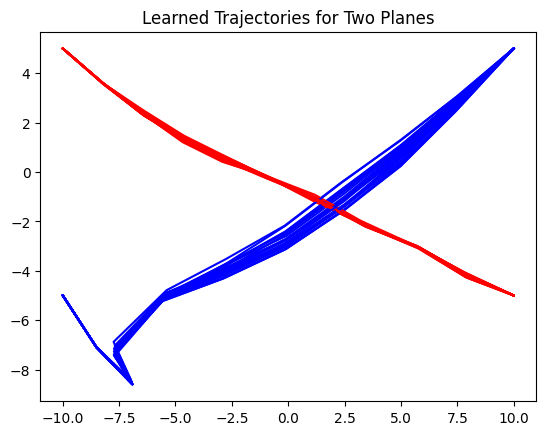

In [105]:
for pth in range(n):
    plt.plot(current_paths[pth * num_policies, :, 0].detach().cpu().numpy(), 
             current_paths[pth * num_policies, :, 1].detach().cpu().numpy(), color = 'red')
    plt.plot(current_paths2[pth * num_policies, :, 0].detach().cpu().numpy(), 
             current_paths2[pth * num_policies, :, 1].detach().cpu().numpy(), color = 'blue')
plt.title("Learned Trajectories for Two Planes")

In [106]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def interpolate_trajectory(positions, n_interp=10):
    """
    Linearly interpolate positions between timesteps to make animation smoother.
    positions: [T, 4] (single sample)
    Returns: [T * n_interp, 4]
    """
    T = positions.shape[0]
    interp_positions = []
    for t in range(T - 1):
        start = positions[t]
        end = positions[t + 1]
        for i in range(n_interp):
            alpha = i / n_interp
            interp = (1 - alpha) * start + alpha * end
            interp_positions.append(interp)
    interp_positions.append(positions[-1])  # include last timestep
    return np.stack(interp_positions, axis=0)

def animate_smooth_positions(current_paths, current_paths2, sample_idx=0, interval=50, n_interp=10):
    pos1 = current_paths[sample_idx].detach().cpu().numpy()  # [T, 2]
    smooth_pos1 = interpolate_trajectory(pos1, n_interp=n_interp)
    
    pos2 = current_paths2[sample_idx].detach().cpu().numpy()  # [T, 2]
    smooth_pos2 = interpolate_trajectory(pos2, n_interp=n_interp)

    x1, y1 = smooth_pos1[:, 0], smooth_pos1[:, 1]
    x2, y2 = smooth_pos2[:, 0], smooth_pos2[:, 1]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_xlim(-12, 10)
    ax.set_ylim(-10, 10)

    line1, = ax.plot([], [], 'b-', label='Plane 1')
    line2, = ax.plot([], [], 'r-', label='Plane 2')
    point1, = ax.plot([], [], 'bo')
    point2, = ax.plot([], [], 'ro')
    ax.legend()

    def init():
        line1.set_data([], [])
        line2.set_data([], [])
        point1.set_data([], [])
        point2.set_data([], [])
        return line1, line2, point1, point2

    def update(frame):
        line1.set_data(x1[:frame+1], y1[:frame+1])
        line2.set_data(x2[:frame+1], y2[:frame+1])
        point1.set_data([x1[frame]], [y1[frame]])
        point2.set_data([x2[frame]], [y2[frame]])
        return line1, line2, point1, point2

    ani = FuncAnimation(fig, update, frames=len(x1), init_func=init, interval=interval, blit=False)
    return HTML(ani.to_jshtml())




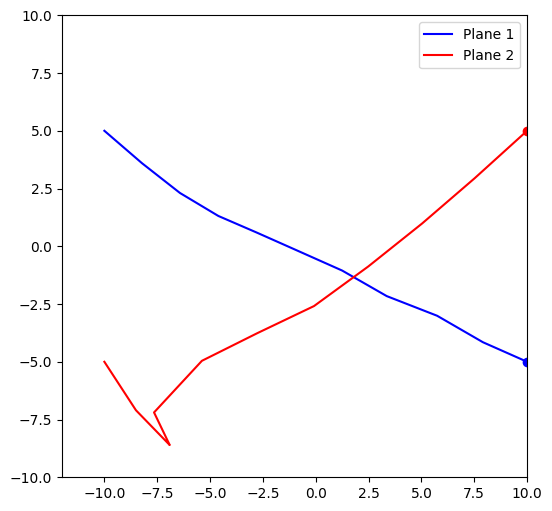

In [107]:
animate_smooth_positions(current_paths, current_paths2, sample_idx=3, interval=150, n_interp=10)

In [106]:
pos = current_paths[0, :, :].detach().cpu().numpy()
x1, y1 = pos[:, 0], pos[:, 1]
x2, y2 = pos[:, 2], pos[:, 3]

In [22]:
interact(
    plot_quiver,
    model_idx=IntSlider(min=0, max=len(models_erm)-1, step=1, description='Model'),
    z_idx=IntSlider(min=0, max=len(Zs)-1, step=1, description='Z index')
)
plt.show()

interactive(children=(IntSlider(value=0, description='Model', max=8), IntSlider(value=0, description='Z index'…